<a href="https://colab.research.google.com/github/Visionary-DataWorks/DSPL-Project/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Functions
import pandas as pd

In [2]:

#Load the preprocessed dataset
data=pd.read_csv('/content/cleaned_train_data.csv')

In [4]:
#print head
data.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4


In [3]:

#Checking missing values
print(data.info())
print(data.isnull().sum)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774148 entries, 0 to 774147
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Customer_ID       774146 non-null  float64
 1   outlet_city       774148 non-null  object 
 2   luxury_sales      774148 non-null  float64
 3   fresh_sales       774148 non-null  float64
 4   dry_sales         774148 non-null  float64
 5   cluster_category  774148 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 35.4+ MB
None
<bound method DataFrame.sum of         Customer_ID  outlet_city  luxury_sales  fresh_sales  dry_sales  \
0             False        False         False        False      False   
1             False        False         False        False      False   
2             False        False         False        False      False   
3             False        False         False        False      False   
4             False        False     

In [5]:
print(data.columns)

Index(['Customer_ID', 'outlet_city', 'luxury_sales', 'fresh_sales',
       'dry_sales', 'cluster_category'],
      dtype='object')


In [6]:
#Define Features (X)and Target (Y)
x = data.drop(columns=['cluster_category','Customer_ID']) #independent variables
y = data['cluster_category'] #Target variable

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (774148, 4)
Target shape: (774148,)


In [7]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for outlet city
le = LabelEncoder()
x['outlet_city'] = le.fit_transform(x['outlet_city'])

In [8]:
from sklearn.model_selection import train_test_split

#splitting data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state= 42, stratify= y)

print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Training set size: (619318, 4)
Testing set size: (154830, 4)


In [9]:
#check shape for whole dataset
print('Whole Data shape', data.shape)

Whole Data shape (774148, 6)


In [10]:
from sklearn. preprocessing import RobustScaler

#initialize scaler()
scaler = RobustScaler()

#fit &transform training data, transform testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
#create a new random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [13]:
# Make predictions
y_pred = rf_model.predict(x_test_scaled)

In [14]:
#To see the predicted values
print("Predicted Values: ", y_pred)

Predicted Values:  [5 4 4 ... 4 3 1]


[[37776     1     1    18     0     1]
 [    0 31002     1     1     0     9]
 [    1     0  9778     1     1     0]
 [   18     0     2 34465     3     0]
 [    1     0    17     2  7887     1]
 [    0    21     4     2     1 33815]]


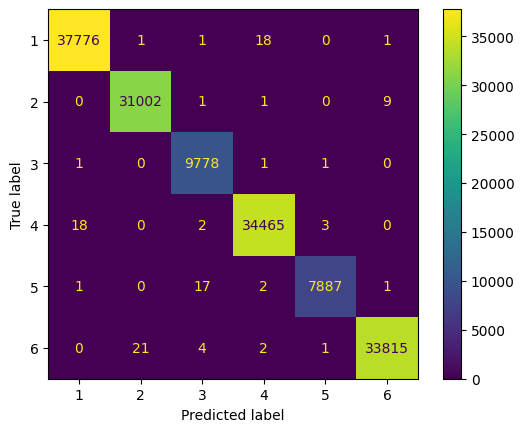

In [16]:
# plot of the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_m = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_m, display_labels=rf_model.classes_)
disp.plot()
print(confusion_m)

In [17]:
#import the function calculate accuracy score
from sklearn.metrics import accuracy_score
# Apply the function to find the correct predictions
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.999308919460053


In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37797
           2       1.00      1.00      1.00     31013
           3       1.00      1.00      1.00      9781
           4       1.00      1.00      1.00     34488
           5       1.00      1.00      1.00      7908
           6       1.00      1.00      1.00     33843

    accuracy                           1.00    154830
   macro avg       1.00      1.00      1.00    154830
weighted avg       1.00      1.00      1.00    154830



ROC Curve

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,RocCurveDisplay,roc_auc_score,auc
from sklearn.preprocessing import label_binarize

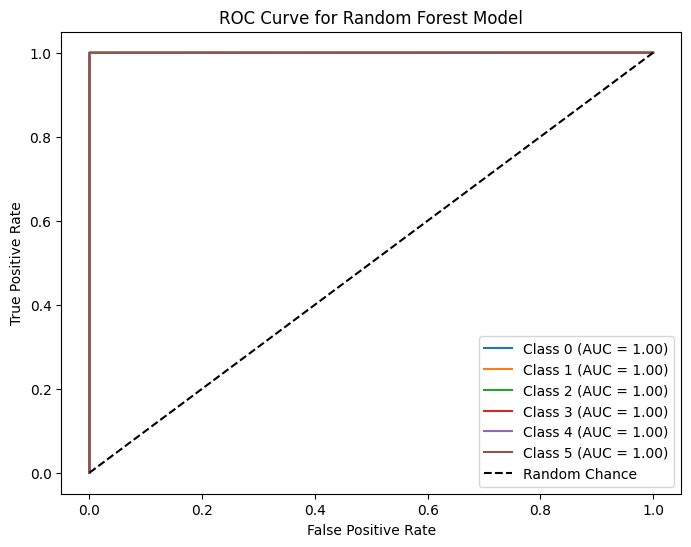

In [27]:
# Import necessary libraries for ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize target labels (needed for multi-class ROC)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Get model probabilities
y_score = rf_model.predict_proba(x_test_scaled)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest Model")
plt.legend(loc="lower right")
plt.show()

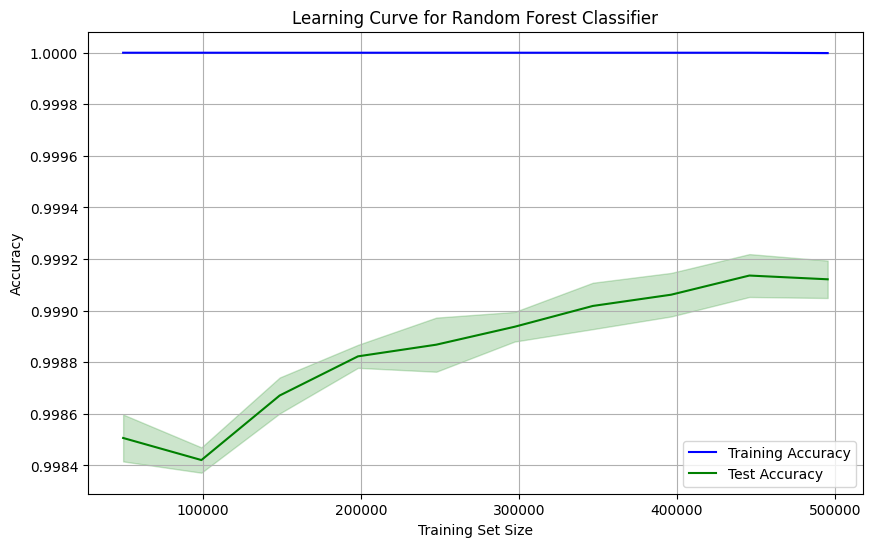

In [29]:
from sklearn.model_selection import learning_curve

#define train sizes
train_sizes, train_scores,test_scores = learning_curve(rf_model, x_train_scaled, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))
#compare mean and std
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue')
plt.plot(train_sizes, test_mean, label='Test Accuracy', color='green')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')


plt.title('Learning Curve for Random Forest Classifier')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()